In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

plt.style.use("plots.mplstyle")

In [2]:
POWERSTUDY8_DIR = Path(r"D:\cw_odmr_lock_in\powerstudy8")
POWERSTUDY8_PREFIX = "powerstudy8"
POWERSTUDY8_POWERS_DBM = [0, -5, -10, -15, -20, -25]


def power_tag(power_dbm):
    """Filename tag for a drive power, e.g. 0 -> 'p0dBm', -5 -> 'pm5dBm'."""
    if power_dbm >= 0:
        return f"p{power_dbm}dBm"
    return f"pm{abs(power_dbm)}dBm"


def load_power_level_repeats(data_dir, prefix, power_dbm):
    """Load every repeat's X/Y for one drive power and return (freqs_hz, r_repeats).

    r_repeats has shape (n_repeats, n_freqs).
    """
    tag = power_tag(power_dbm)
    repeat_files = sorted(
        data_dir.glob(f"{prefix}_{tag}_repeat*_x.npy"),
        key=lambda p: int(p.stem.split("repeat")[1].split("_")[0]),
    )
    freqs_hz = np.load(data_dir / f"{prefix}_{tag}_repeat0_freqs_hz.npy")
    r_repeats = []
    for x_file in repeat_files:
        repeat_id = x_file.stem.split("_repeat")[1].split("_")[0]
        x = np.load(x_file)
        y = np.load(data_dir / f"{prefix}_{tag}_repeat{repeat_id}_y.npy")
        r_repeats.append(np.hypot(x, y))
    return freqs_hz, np.array(r_repeats)


def mean_and_sem(values, axis=0):
    """Mean and standard error of the mean along axis."""
    mean = values.mean(axis=axis)
    sem = values.std(axis=axis, ddof=1) / np.sqrt(values.shape[axis])
    return mean, sem

In [3]:
def lorentzian(f, amp, center, width):
    return amp * width**2 / ((f - center) ** 2 + width**2)


def double_lorentzian(f, offset, amp1, center1, width1, amp2, center2, width2):
    return (
        offset
        + lorentzian(f, amp1, center1, width1)
        + lorentzian(f, amp2, center2, width2)
    )


def fit_double_lorentzian(freqs_mhz, y):
    """Fit y(freqs_mhz) to a constant offset plus two Lorentzians. Returns popt."""
    f_min, f_max = freqs_mhz.min(), freqs_mhz.max()
    f_range = f_max - f_min
    offset0 = np.median(y)
    amp0 = np.min(y) - np.max(y)
    width0 = f_range / 10
    p0 = [
        offset0,
        amp0,
        f_min + f_range / 3,
        width0,
        amp0,
        f_min + 2 * f_range / 3,
        width0,
    ]
    popt, _ = curve_fit(double_lorentzian, freqs_mhz, y, p0=p0, maxfev=20000)
    return popt

In [4]:
def fit_power_levels(data_dir, prefix, powers_dbm):
    """Load and fit each power level. Returns a list of result dicts."""
    results = []
    for power_dbm in powers_dbm:
        freqs_hz, r_repeats = load_power_level_repeats(data_dir, prefix, power_dbm)
        r_mean, r_sem = mean_and_sem(r_repeats)
        freqs_mhz = freqs_hz / 1e6
        r_mean_uv = r_mean * 1e6
        r_sem_uv = r_sem * 1e6
        popt = fit_double_lorentzian(freqs_mhz, r_mean_uv)
        results.append(
            {
                "power_dbm": power_dbm,
                "freqs_mhz": freqs_mhz,
                "r_mean_uv": r_mean_uv,
                "r_sem_uv": r_sem_uv,
                "popt": popt,
            }
        )
    return results


def plot_power_series(ax, results):
    for result in results:
        errorbar = ax.errorbar(
            result["freqs_mhz"],
            result["r_mean_uv"],
            yerr=result["r_sem_uv"],
            fmt="o",
            markersize=1,
            capsize=2,
            label=f"{result['power_dbm']} dBm",
        )
        color = errorbar.lines[0].get_color()

        freqs_dense_mhz = np.linspace(
            result["freqs_mhz"].min(), result["freqs_mhz"].max(), 1000
        )
        ax.plot(
            freqs_dense_mhz,
            double_lorentzian(freqs_dense_mhz, *result["popt"]),
            linestyle=":",
            color=color,
        )
    ax.set_xlabel("frequency [MHz]")
    ax.set_ylabel("lockin signal amplitude [uV]")
    ax.legend()


def print_peak_table(results):
    header = f"{'power [dBm]':>12} {'peak 1 [MHz]':>13} {'FWHM 1 [MHz]':>13} {'peak 2 [MHz]':>13} {'FWHM 2 [MHz]':>13}"
    print(header)
    for result in results:
        _, _, center1, width1, _, center2, width2 = result["popt"]
        print(
            f"{result['power_dbm']:>12} "
            f"{center1:>13.3f} {2 * abs(width1):>13.3f} "
            f"{center2:>13.3f} {2 * abs(width2):>13.3f}"
        )

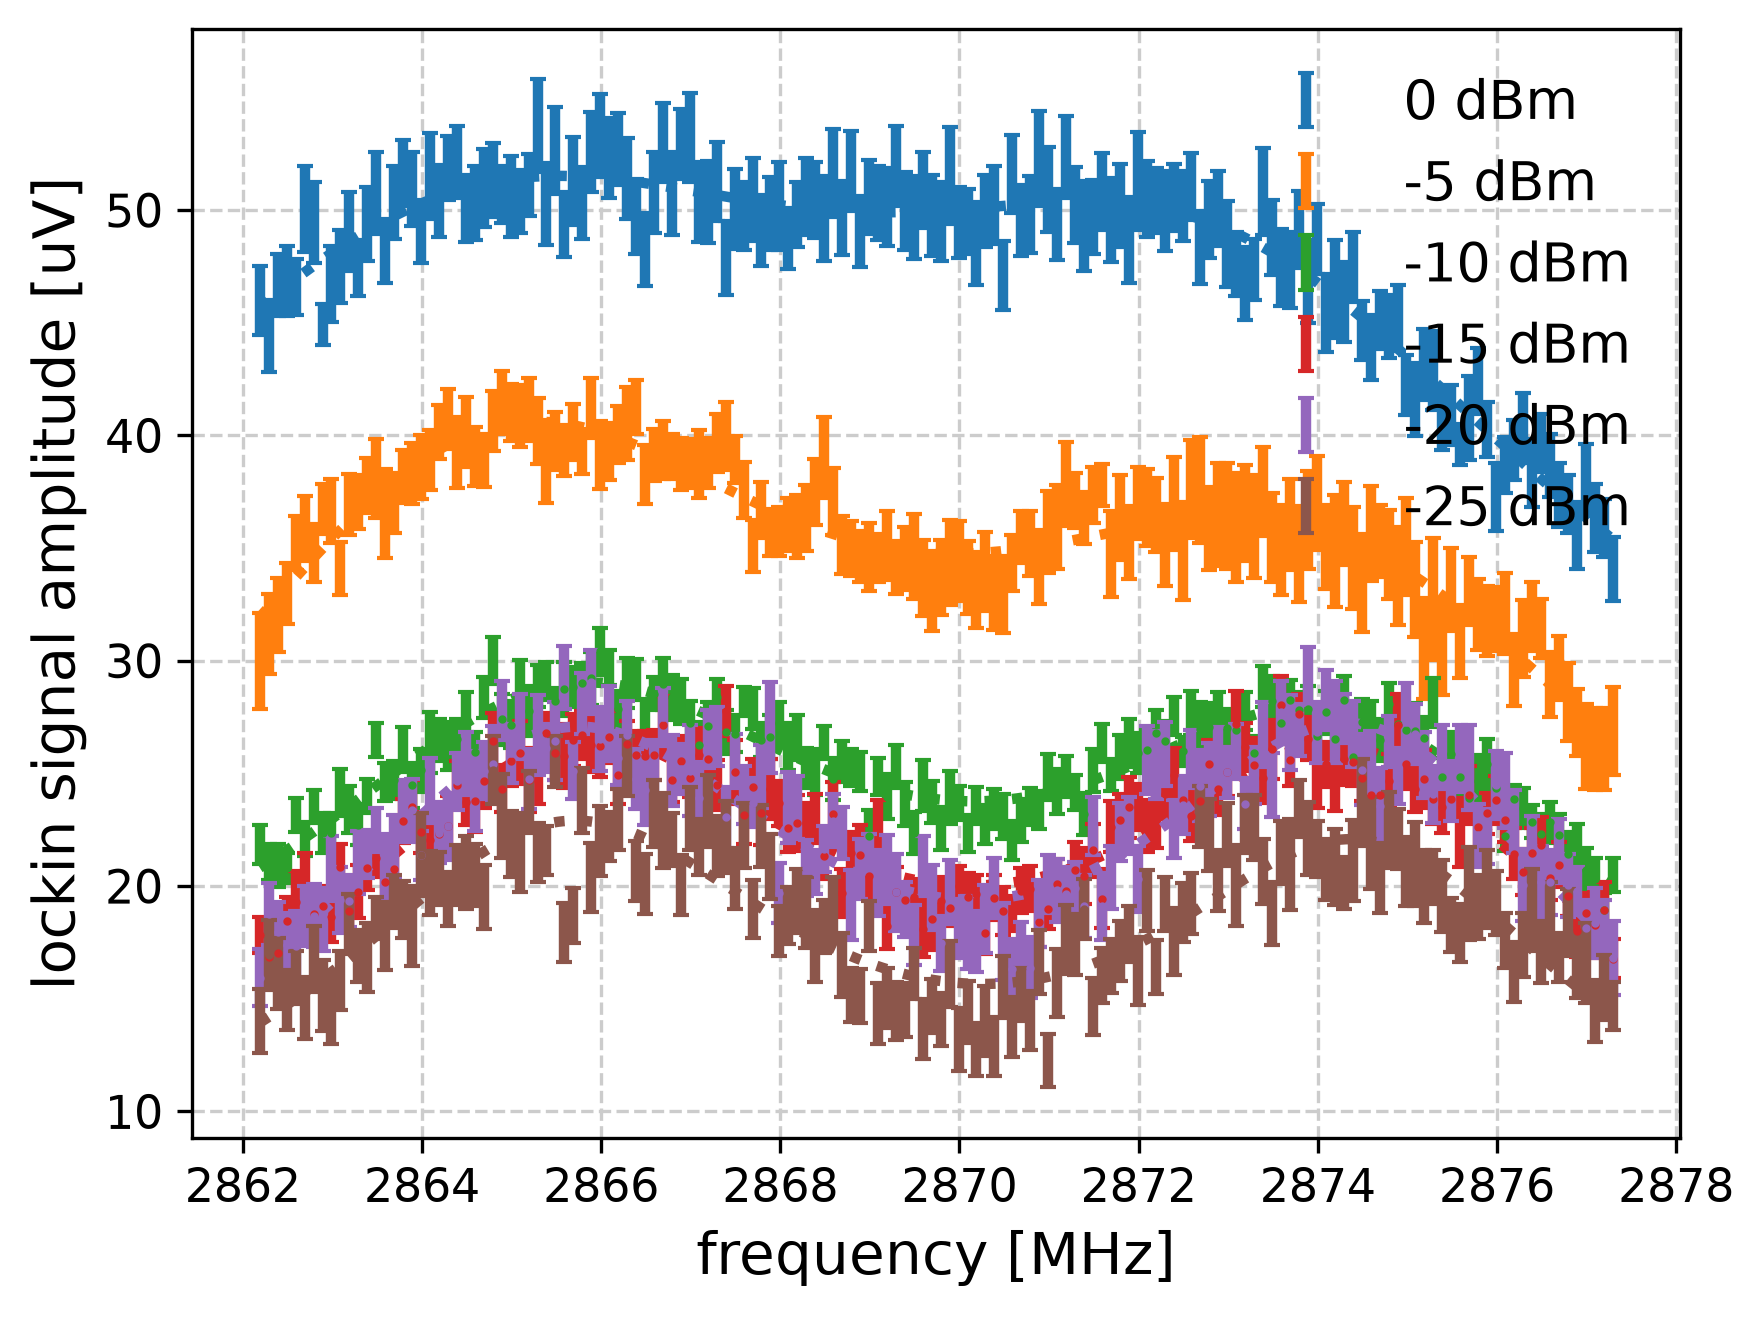

 power [dBm]  peak 1 [MHz]  FWHM 1 [MHz]  peak 2 [MHz]  FWHM 2 [MHz]
           0      2864.445        12.567      2872.836        10.804
          -5      2864.764         9.937      2873.943        11.089
         -10      2865.655         7.747      2874.155         6.905
         -15      2865.781         6.488      2874.280         6.069
         -20      2865.591         7.246      2874.458         6.442
         -25      2865.602         6.714      2874.492         6.003


In [5]:
results = fit_power_levels(POWERSTUDY8_DIR, POWERSTUDY8_PREFIX, POWERSTUDY8_POWERS_DBM)

fig, ax = plt.subplots(dpi=300)
plot_power_series(ax, results)
plt.show()

print_peak_table(results)

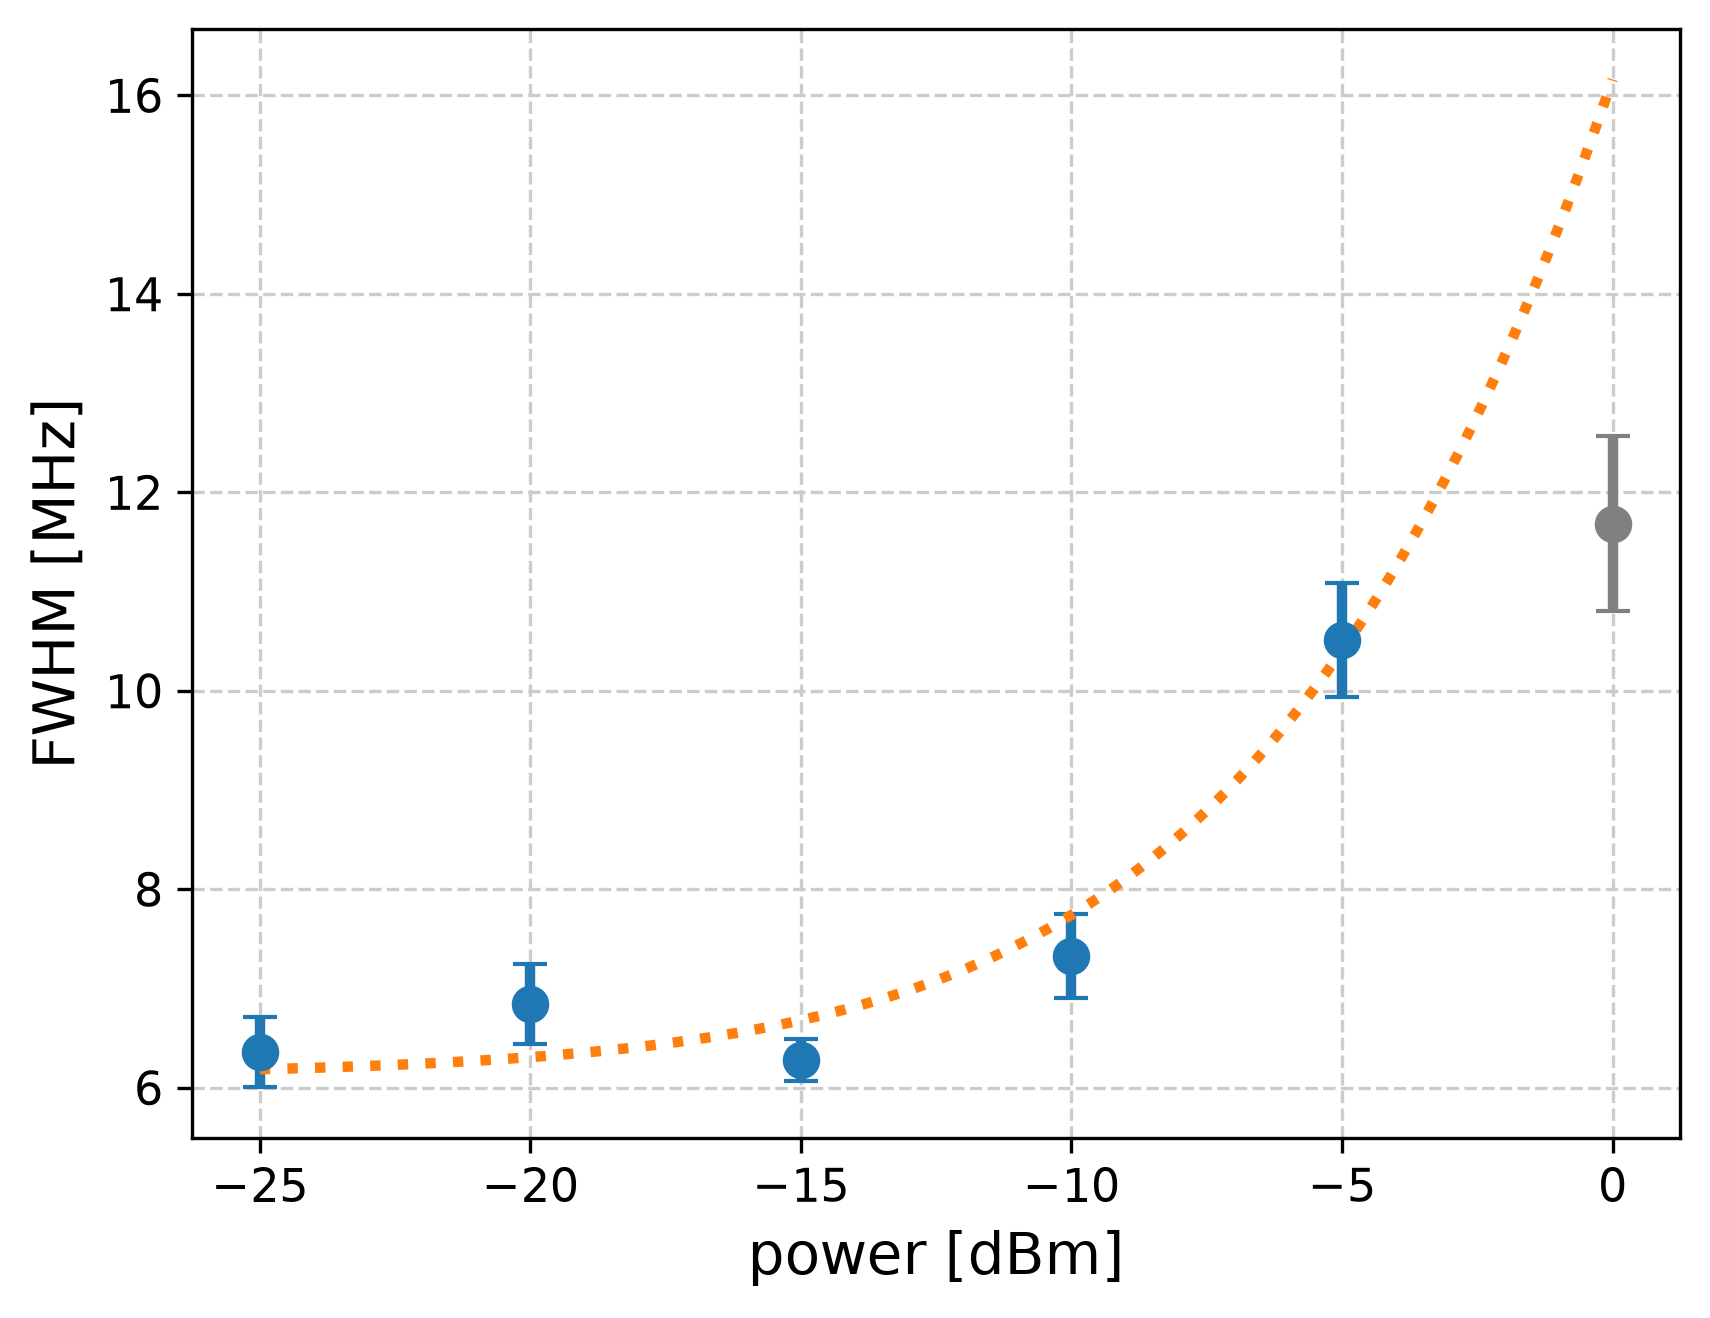

Gamma0 = 6.129 MHz, c = 223.609 MHz^2/mW


In [6]:
def power_dbm_to_mw(power_dbm):
    return 10 ** (power_dbm / 10)


def power_broadening_model(power_mw, gamma0_sq, c):
    """FWHM^2 = Gamma0^2 + c * P."""
    return gamma0_sq + c * power_mw


def fit_power_broadening(powers_dbm, fwhm_mhz):
    powers_mw = power_dbm_to_mw(np.asarray(powers_dbm))
    popt, _ = curve_fit(
        power_broadening_model, powers_mw, np.asarray(fwhm_mhz) ** 2
    )
    return popt


def plot_power_vs_fwhm(ax, results, excluded_powers_dbm=()):
    powers_dbm = np.array([result["power_dbm"] for result in results])
    fwhm_pairs = np.array(
        [[2 * abs(result["popt"][3]), 2 * abs(result["popt"][6])] for result in results]
    )
    fwhm_mean, fwhm_sem = mean_and_sem(fwhm_pairs, axis=1)

    excluded = np.isin(powers_dbm, excluded_powers_dbm)

    ax.errorbar(
        powers_dbm[~excluded],
        fwhm_mean[~excluded],
        yerr=fwhm_sem[~excluded],
        fmt="o",
        markersize=8,
        capsize=4,
    )
    ax.errorbar(
        powers_dbm[excluded],
        fwhm_mean[excluded],
        yerr=fwhm_sem[excluded],
        fmt="o",
        markersize=8,
        capsize=4,
        color="gray",
    )

    popt = fit_power_broadening(powers_dbm[~excluded], fwhm_mean[~excluded])
    powers_dbm_dense = np.linspace(powers_dbm.min(), powers_dbm.max(), 200)
    fwhm_fit = np.sqrt(power_broadening_model(power_dbm_to_mw(powers_dbm_dense), *popt))
    ax.plot(powers_dbm_dense, fwhm_fit, linestyle=":")

    ax.set_xlabel("power [dBm]")
    ax.set_ylabel("FWHM [MHz]")
    return popt


fig, ax = plt.subplots(dpi=300)
gamma0_sq, c = plot_power_vs_fwhm(ax, results, excluded_powers_dbm=[0])
plt.show()

print(f"Gamma0 = {np.sqrt(gamma0_sq):.3f} MHz, c = {c:.3f} MHz^2/mW")